# Shallow xLSTM Benchmark with Optuna & Symlog

In [1]:
!pip install optuna xlstm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.7/91.7 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 91.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 126.4 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import torch
import torch.nn as nn
from sklearn.preprocessing import RobustScaler
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
import optuna

from xlstm import (
    xLSTMBlockStack,
    xLSTMBlockStackConfig,
    sLSTMBlockConfig,
    mLSTMBlockConfig,
    sLSTMLayerConfig,
    mLSTMLayerConfig
)


DATA_PATH = Path("Merged_Dataset_yoy.csv")
PREDICTION_TARGETS = ["EBITDA", "Net_Income", "ROA"]
DEFAULT_LOOKBACK_DAYS = 365

MAX_EPOCHS = 70
PATIENCE = 10
TEST_YEAR_CUTOFF = 2023
N_SPLITS = 5
OPTUNA_TRIALS = 25
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## Data Loading

In [ ]:
def load_and_prepare_yoy_data(data_path: Path, lookback_days: int = 365):
    try:
        df = pd.read_csv(data_path, low_memory=False)
    except FileNotFoundError:
        df = pd.read_csv("Merged_Dataset_yoy.csv", low_memory=False)

    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values(["Company", "Date"]).reset_index(drop=True)
    df["year"] = df["Date"].dt.year

    # Derived company-specific features (size-neutral transforms)
    df["Close_logret"] = df.groupby("Company")["Close"].transform(lambda x: np.log(x / x.shift(1)))
    df["Volume_log"] = np.log1p(df["Volume"].clip(lower=0))

    df["has_targets"] = df[PREDICTION_TARGETS].notna().any(axis=1)
    year_end_records = df[df["has_targets"]].copy()

    exclude_cols = {"Date", "Company", "year", "has_targets"} | set(PREDICTION_TARGETS)
    feature_cols = [col for col in df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]

    sequences = []
    for company in df["Company"].unique():
        company_records = year_end_records[year_end_records["Company"] == company].copy()
        company_data = df[df["Company"] == company].copy()

        for _, year_end_row in company_records.iterrows():
            year = int(year_end_row["year"])
            year_end_date = year_end_row["Date"]

            prior_year_records = year_end_records[
                (year_end_records["Company"] == company) & (year_end_records["year"] == year - 1)
            ]
            if prior_year_records.empty:
                continue

            prior_row = prior_year_records.iloc[0]
            historical_data = company_data[company_data["Date"] <= year_end_date]
            if len(historical_data) < lookback_days:
                continue

            window = historical_data.tail(lookback_days).copy()

            window[feature_cols] = window[feature_cols].ffill().bfill()
            if window[feature_cols].isna().any().any():
                continue

            static_cols = ["MC_MIB", "MC_MID", "MC_SMALL"]
            static_data = window[static_cols].iloc[-1].to_numpy(dtype=np.float32)

            sequences.append({
                "company": company, "year": year, "year_end_date": year_end_date,
                "window_data": window[feature_cols].to_numpy(dtype=np.float32),
                "static_data": static_data,
                **{f"current_{t.lower()}": year_end_row[t] for t in PREDICTION_TARGETS},
                **{f"prior_{t.lower()}": prior_row[t] for t in PREDICTION_TARGETS},
            })

    data_records = []
    for seq in sequences:
        for target_name in PREDICTION_TARGETS:
            current_val = seq[f"current_{target_name.lower()}"]
            prior_val = seq[f"prior_{target_name.lower()}"]
            if pd.isna(current_val) or pd.isna(prior_val):
                continue
            label_value = (current_val - prior_val) / (np.abs(prior_val) + 1e-8)
            data_records.append({
                "company": seq["company"], "year": seq["year"], "year_end_date": seq["year_end_date"],
                "target": target_name, "label_value": label_value,
                "window_data": seq["window_data"],
                "static_data": seq["static_data"]
            })

    return pd.DataFrame(data_records), feature_cols

def temporal_kfold_split(df: pd.DataFrame, n_splits: int = N_SPLITS, test_year_cutoff: int = TEST_YEAR_CUTOFF):
    if df.empty:
        raise ValueError("The dataset is empty. Check if DEFAULT_LOOKBACK_DAYS is too small.")
    available_years = sorted(int(y) for y in df["year"].unique())
    pre_test_years = [y for y in available_years if y <= test_year_cutoff]
    print(f"Available years in dataset: {available_years}")
    if len(pre_test_years) < n_splits + 1:
        raise ValueError(f"Not enough pre-test years ({len(pre_test_years)}) for {n_splits} folds (need >= {n_splits+1}).")
    val_years = pre_test_years[-n_splits:]
    test_set = df[df["year"] > test_year_cutoff].copy()
    print(f"Test: > {test_year_cutoff} ({len(test_set)} samples)")
    print(f"Temporal k-fold ({n_splits} folds, expanding window). Val years: {val_years}")
    folds = []
    for fold_idx, vy in enumerate(val_years, start=1):
        train_set = df[df["year"] < vy].copy()
        val_set = df[df["year"] == vy].copy()
        if train_set.empty or val_set.empty:
            print(f"WARNING: fold {fold_idx} (val {vy}) has empty train ({len(train_set)}) or val ({len(val_set)}). Skipping.")
            continue
        folds.append((train_set, val_set, vy, fold_idx))
        print(f"  Fold {fold_idx}: train <= {vy-1} ({len(train_set)}), val = {vy} ({len(val_set)})")
    if not folds:
        raise ValueError("No valid folds produced.")
    return folds, test_set

def split_to_single(df: pd.DataFrame, test_year_cutoff: int = TEST_YEAR_CUTOFF):
    folds, test_set = temporal_kfold_split(df, n_splits=1, test_year_cutoff=test_year_cutoff)
    train_set, val_set, val_year, _ = folds[-1]
    return train_set, val_set, test_set

def make_robust_scaler(train_df: pd.DataFrame, feature_indices):
    sc = RobustScaler()
    train_windows = np.vstack([row[:, feature_indices] for row in train_df["window_data"]])
    sc.fit(train_windows)
    return sc

data_df, feature_cols = load_and_prepare_yoy_data(DATA_PATH, lookback_days=DEFAULT_LOOKBACK_DAYS)

WINSOR_CAP = 3.0
NEW_STATIC_SLICE = slice(3, 9)

improved_data_df = data_df.copy()
idx_value = improved_data_df["target"].isin(PREDICTION_TARGETS)
y_val = improved_data_df.loc[idx_value, "label_value"].to_numpy()
capped = np.clip(y_val, -WINSOR_CAP, WINSOR_CAP)
improved_data_df.loc[idx_value, "label_value"] = (np.sign(capped) * np.log1p(np.abs(capped))).astype(np.float32)
n_capped = int(np.sum(np.abs(y_val) > WINSOR_CAP))
print(f"Robust symlog label: capped {n_capped}/{len(y_val)} ({100.0*n_capped/len(y_val):.2f}%) at +/-{int(WINSOR_CAP)}.")

# Add fundamentals + prior-year target levels as static features
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
df_raw["Date"] = pd.to_datetime(df_raw["Date"])
df_raw["year"] = df_raw["Date"].dt.year
has_targets_raw = df_raw[PREDICTION_TARGETS].notna().any(axis=1)
year_end_raw = df_raw[has_targets_raw].copy()

fund_map = {}
for _, r in year_end_raw.iterrows():
    vals = [r[t] for t in PREDICTION_TARGETS] + [r["Total_Assets"], r["Total_Debt"], r["Cash"]]
    if any(pd.isna(v) for v in vals):
        continue
    fund_map[(r["Company"], int(r["year"]))] = {
        "EBITDA": float(r["EBITDA"]), "Net_Income": float(r["Net_Income"]), "ROA": float(r["ROA"]),
        "Total_Assets": float(r["Total_Assets"]), "Total_Debt": float(r["Total_Debt"]), "Cash": float(r["Cash"]),
    }
print(f"Fundamentals map: {len(fund_map)} (company, year) entries with all 6 fields.")

keep_idx, new_static_list = [], []
n_drop_missing = 0
for idx, row in improved_data_df.iterrows():
    key = (row["company"], int(row["year"]) - 1)
    if key not in fund_map:
        n_drop_missing += 1
        continue
    p = fund_map[key]
    mc = np.asarray(row["static_data"], dtype=np.float32)
    assets = p["Total_Assets"]
    prior_ebitda_sl = np.sign(p["EBITDA"]) * np.log1p(np.abs(p["EBITDA"]))
    prior_ni_sl     = np.sign(p["Net_Income"]) * np.log1p(np.abs(p["Net_Income"]))
    prior_roa       = p["ROA"]
    leverage        = p["Total_Debt"] / (np.abs(assets) + 1e-8)
    cash_ratio      = p["Cash"] / (np.abs(assets) + 1e-8)
    size_sl         = np.sign(assets) * np.log1p(np.abs(assets))
    static_imp = np.concatenate([mc, [prior_ebitda_sl, prior_ni_sl, prior_roa,
                                      leverage, cash_ratio, size_sl]]).astype(np.float32)
    new_static_list.append(static_imp)
    keep_idx.append(idx)

improved_data_df = improved_data_df.loc[keep_idx].copy()
improved_data_df["static_data"] = new_static_list
print(f"Dropped {n_drop_missing} samples missing prior-year fundamentals; {len(improved_data_df)} remaining.")

# k-fold for HPO and single-split for final-test paths (matches LSTM notebook)
folds_imp_raw, test_data_imp_raw = temporal_kfold_split(improved_data_df, n_splits=N_SPLITS, test_year_cutoff=TEST_YEAR_CUTOFF)
train_data_imp_s, val_data_imp_s, _ = split_to_single(improved_data_df, test_year_cutoff=TEST_YEAR_CUTOFF)
# single-split train/val for final eval; test from k-fold test set
train_data_imp = train_data_imp_s
val_data_imp = val_data_imp_s
test_data_imp = test_data_imp_raw

SELECTED_FEATURES = [
    'Close_logret', 'Volume_log',
    'DE10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 'Euribor_3M', 'FTMIB_Volume',
    'GVZ_Close', 'IT_Inflation', 'Brent_Close', 'OVX_Close', 'TTF_Gas_Close',
    'VIX_Close', 'Gold_Close', 'YC__level', 'YC__slope', 'YC__curv',
    'PCOPPUSDM', 'PALUMUSDM', 'NFCI', 'ff_HML', 'ff_Mom',
    'FTMIB_Close', 'IT10YT_Yield', 'IT_Unemployment', 'Brent_Volume'
]
STATIC_FEATURES = ['MC_MIB', 'MC_MID', 'MC_SMALL']
STATIC_DIM = 9  # 3 MC dummies + 6 fundamental features

selected_indices = [feature_cols.index(f) for f in SELECTED_FEATURES]
robust_scaler = RobustScaler()
train_windows_imp = np.vstack([row[:, selected_indices] for row in train_data_imp["window_data"]])
robust_scaler.fit(train_windows_imp)

# Static-feature scaler: RobustScaler on the 6 new dims (MC dummies pass through)
static_scaler = RobustScaler()
static_train_arr = np.vstack([row for row in train_data_imp["static_data"]]).astype(np.float32)
static_scaler.fit(static_train_arr[:, NEW_STATIC_SLICE])

def apply_static_scaler_to_df(df, sc, new_slice=NEW_STATIC_SLICE):
    df = df.copy()
    statics = np.vstack([row for row in df["static_data"]]).astype(np.float32)
    statics[:, new_slice] = sc.transform(statics[:, new_slice]).astype(np.float32)
    df["static_data"] = [statics[i] for i in range(len(statics))]
    return df

train_data_imp = apply_static_scaler_to_df(train_data_imp, static_scaler)
val_data_imp   = apply_static_scaler_to_df(val_data_imp, static_scaler)
test_data_imp  = apply_static_scaler_to_df(test_data_imp, static_scaler)

print(f"Data Processed. Training sets: {len(train_data_imp)}")
print(f"Selected temporal features ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}")
print(f"Static features ({len(STATIC_FEATURES)}): {STATIC_FEATURES} + 6 fundamental = {STATIC_DIM} total")

Robust symlog label: capped 516/5508 (9.37%) at +/-3.
Fundamentals map: 2106 (company, year) entries with all 6 fields.
Dropped 70 samples missing prior-year fundamentals; 5438 remaining.
Available years in dataset: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Test: > 2023 (493 samples)
Temporal k-fold (5 folds, expanding window). Val years: [2019, 2020, 2021, 2022, 2023]
  Fold 1: train <= 2018 (2703), val = 2019 (412)
  Fold 2: train <= 2019 (3115), val = 2020 (431)
  Fold 3: train <= 2020 (3546), val = 2021 (451)
  Fold 4: train <= 2021 (3997), val = 2022 (459)
  Fold 5: train <= 2022 (4456), val = 2023 (489)
Available years in dataset: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Test: > 2023 (493 samples)
Temporal k-fold (1 folds, expanding window). Val years: [2023]
  Fold 1: train <= 2022 (4456), val = 2023 (489)
Data Processed. Training sets: 4456
Selected temporal features (26): ['Close_logret', 'V

## Dataset and Multi-Task Preparation

In [4]:
def extract_mtl_df(df: pd.DataFrame) -> pd.DataFrame:
    mtl_records = []
    for (company, year), group in df.groupby(["company", "year"]):
        window_data = group.iloc[0]["window_data"]
        year_end_date = group.iloc[0]["year_end_date"]
        static_data = group.iloc[0]["static_data"]
        label_value = np.full(len(PREDICTION_TARGETS), np.nan, dtype=np.float32)
        for i, t in enumerate(PREDICTION_TARGETS):
            t_row = group[group["target"] == t]
            if not t_row.empty:
                label_value[i] = t_row.iloc[0]["label_value"]
        mtl_records.append({
            "company": company, "year": year, "year_end_date": year_end_date,
            "window_data": window_data, "static_data": static_data,
            "label_value": label_value
        })
    return pd.DataFrame(mtl_records)

# k-fold MTL lists for HPO: each entry = (mtl_train, mtl_val, val_year, fold_idx)
folds_mtl = [(extract_mtl_df(tr), extract_mtl_df(va), vy, fi) for (tr, va, vy, fi) in folds_imp_raw]

# Single-split MTL globals (largest fold + held-out test) for final-test evaluation paths
mtl_train_data = extract_mtl_df(train_data_imp)
mtl_val_data = extract_mtl_df(val_data_imp)
mtl_test_data = extract_mtl_df(test_data_imp)

class ImprovedYoYDatasetMTL(Dataset):
    def __init__(self, data_df, scaler, feature_indices):
        self.data_df = data_df.reset_index(drop=True)
        self.scaler = scaler
        self.feature_indices = feature_indices

    def __len__(self): return len(self.data_df)

    def __getitem__(self, idx):
        row = self.data_df.iloc[idx]
        window = row["window_data"][:, self.feature_indices].copy()
        if self.scaler: window = self.scaler.transform(window)
        static = row["static_data"].astype(np.float32)
        target = row["label_value"]
        mask = ~np.isnan(target)
        target_clean = np.nan_to_num(target, nan=0.0)
        return torch.from_numpy(window), torch.from_numpy(static), torch.tensor(target_clean, dtype=torch.float32), torch.tensor(mask, dtype=torch.bool), len(window)

def collate_fn_improved_mtl(batch):
    batch.sort(key=lambda x: x[4], reverse=True)
    sequences = [x[0] for x in batch]
    statics = torch.stack([x[1] for x in batch])
    targets = torch.stack([x[2] for x in batch])
    masks = torch.stack([x[3] for x in batch])
    lengths = torch.tensor([x[4] for x in batch])
    # xLSTM does not use torch packing natively. We feed it zero-padded batches.
    padded_seqs = torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True)
    return padded_seqs, targets, masks, statics, lengths

## xLSTM Model

In [5]:
class ImprovedShallow_xLSTM(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_targets: int = len(PREDICTION_TARGETS), dropout: float = 0.2, block_type: str = 'mlstm', static_dim: int = 0):
        super().__init__()
        self.static_dim = static_dim
        self.proj = nn.Linear(input_size, hidden_size)
        slstm_config = sLSTMLayerConfig(backend='vanilla')

        self.xlstm_config = xLSTMBlockStackConfig(
            slstm_block=sLSTMBlockConfig(slstm=slstm_config),
            mlstm_block=mLSTMBlockConfig(mlstm=mLSTMLayerConfig()),
            context_length=400, # Large enough to encompass max lookback sequence limits
            num_blocks=1, # Depth 1, strictly comparing to shallow LSTM
            embedding_dim=hidden_size,
            slstm_at=[0] if block_type == 'slstm' else []
        )

        self.xlstm = xLSTMBlockStack(self.xlstm_config)
        self.dropout = nn.Dropout(p=dropout)
        self.head = nn.Linear(hidden_size + static_dim, num_targets)

    def forward(self, x, lengths, static=None):
        # x shape: [B, MaxSeq, input_size]
        B, S, _ = x.shape
        x_proj = self.proj(x)

        # Output strictly structured as [B, S, hidden_dim]
        out = self.xlstm(x_proj)

        # Dynamically recover the 'last valid hidden step' taking sequence padding into account
        idx = (lengths - 1).view(-1, 1).expand(-1, out.size(2)).unsqueeze(1).to(out.device)
        last_out = out.gather(1, idx).squeeze(1) # [B, hidden_size]

        hidden = self.dropout(last_out)
        if self.static_dim > 0 and static is not None:
            hidden = torch.cat([hidden, static.to(hidden.device, hidden.dtype)], dim=-1)
        logits = self.head(hidden)

        if logits.size(-1) == 1: logits = logits.squeeze(-1)
        return logits

In [6]:
class TunableHybrid_xLSTM(nn.Module):
    def __init__(self, input_size: int, embedding_dim: int, mlstm_proj_factor: float,
                 mlstm_num_heads: int, slstm_hidden_size: int, dropout_mlstm: float,
                 dropout_slstm: float, dropout_global: float, num_targets: int = len(PREDICTION_TARGETS), static_dim: int = 0):
        super().__init__()
        self.static_dim = static_dim
        self.proj = nn.Linear(input_size, embedding_dim)

        slstm_config = sLSTMLayerConfig(
            backend='vanilla',
            hidden_size=slstm_hidden_size,
            dropout=dropout_slstm
        )

        mlstm_config = mLSTMLayerConfig(
            num_heads=mlstm_num_heads,
            proj_factor=mlstm_proj_factor,
            dropout=dropout_mlstm
        )

        # ... (rest of the __init__ and forward pass remain exactly the same)

        self.xlstm_config = xLSTMBlockStackConfig(
            slstm_block=sLSTMBlockConfig(slstm=slstm_config),
            mlstm_block=mLSTMBlockConfig(mlstm=mlstm_config),
            context_length=400,
            num_blocks=3,
            embedding_dim=embedding_dim,
            slstm_at=[2] # Block 0 & 1 are mLSTM, Block 2 is sLSTM
        )

        self.xlstm = xLSTMBlockStack(self.xlstm_config)
        self.head_dropout = nn.Dropout(p=dropout_global)
        self.head = nn.Linear(embedding_dim + static_dim, num_targets)

    def forward(self, x, lengths, static=None):
        B, S, _ = x.shape
        out = self.proj(x)
        out = self.xlstm(out)

        idx = (lengths - 1).view(-1, 1).expand(-1, out.size(2)).unsqueeze(1).to(out.device)
        last_out = out.gather(1, idx).squeeze(1)

        hidden = self.head_dropout(last_out)
        if self.static_dim > 0 and static is not None:
            hidden = torch.cat([hidden, static.to(hidden.device, hidden.dtype)], dim=-1)
        logits = self.head(hidden)

        if logits.size(-1) == 1: logits = logits.squeeze(-1)
        return logits

def objective_hybrid(trial):
    SEED = 42
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
        torch.backends.cudnn.deterministic = True
    # Core transport bus dimension
    embedding_dim = trial.suggest_categorical("embedding_dim", [32, 64, 128])

    # mLSTM specific settings (Matrix capacity)
    mlstm_proj_factor = trial.suggest_categorical("mlstm_proj_factor", [1.0, 1.5, 2.0])
    mlstm_num_heads = trial.suggest_categorical("mlstm_num_heads", [2, 4])

    # Prune immediately if embedding_dim cannot be evenly divided by heads
    if embedding_dim % mlstm_num_heads != 0:
        raise optuna.TrialPruned()

    # sLSTM specific settings (Scalar tracking capacity)
    slstm_hidden_size = trial.suggest_categorical("slstm_hidden_size", [16, 32, 64])

    # Regularization
    dropout_mlstm = trial.suggest_float("dropout_mlstm", 0.1, 0.4)
    dropout_slstm = trial.suggest_float("dropout_slstm", 0.1, 0.4)
    dropout_global = trial.suggest_float("dropout_global", 0.2, 0.5)

    # Optimizer & Training
    lr_mlstm = trial.suggest_float("lr_mlstm", 1e-4, 5e-3, log=True)
    lr_slstm = trial.suggest_float("lr_slstm", 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    train_ds = ImprovedYoYDatasetMTL(mtl_train_data, robust_scaler, selected_indices)
    val_ds = ImprovedYoYDatasetMTL(mtl_val_data, robust_scaler, selected_indices)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn_improved_mtl)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_improved_mtl)

    model = TunableHybrid_xLSTM(
        input_size=len(selected_indices),
        embedding_dim=embedding_dim,
        mlstm_proj_factor=mlstm_proj_factor,
        mlstm_num_heads=mlstm_num_heads,
        slstm_hidden_size=slstm_hidden_size,
        dropout_mlstm=dropout_mlstm,
        dropout_slstm=dropout_slstm,
        dropout_global=dropout_global,
        static_dim=STATIC_DIM
    )

    mlstm_params = [p for n, p in model.named_parameters() if 'mlstm' in n]
    slstm_params = [p for n, p in model.named_parameters() if 'slstm' in n]
    other_params = [p for n, p in model.named_parameters() if 'mlstm' not in n and 'slstm' not in n]

    optimizer = torch.optim.AdamW([
        {'params': mlstm_params, 'lr': lr_mlstm},
        {'params': slstm_params, 'lr': lr_slstm},
        {'params': other_params, 'lr': lr_mlstm}
    ], weight_decay=weight_decay)

    criterion = RealScaleL1Loss()
    val_loss = train_model_v2(model, train_loader, val_loader, criterion, optimizer,
                           epochs=MAX_EPOCHS, patience=PATIENCE, device=DEVICE, trial=trial)

    return val_loss

## Optuna & Training Loop Helper

In [ ]:
SYMLOG_CAP = float(np.log1p(3.0))

def inverse_symlog_tensor(values):
    values = torch.clamp(values, -SYMLOG_CAP, SYMLOG_CAP)
    return torch.sign(values) * torch.expm1(torch.abs(values))

class RealScaleL1Loss(nn.Module):
    def forward(self, preds_symlog, targets_symlog):
        preds_real = inverse_symlog_tensor(preds_symlog)
        targets_real = inverse_symlog_tensor(targets_symlog)
        return torch.mean(torch.abs(preds_real - targets_real))

def train_model(model, train_loader, val_loader, criterion, lr, weight_decay, epochs, patience, device, trial=None, step_offset=0):
    model.to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=5
    )

    best_loss = float('inf')
    best_epoch = -1
    early_stop_counter = 0
    history = {
        "train_loss": [],
        "val_loss": [],
        "lr": []
    }

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_valid_count = 0

        for x_batch, y_batch, mask_batch, static_batch, lengths in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            mask_batch = mask_batch.to(device)
            static_batch = static_batch.to(device)
            lengths = lengths.to(device)

            if mask_batch.sum() == 0:
                continue

            optimizer.zero_grad()
            preds = model(x_batch, lengths, static_batch)
            valid_count = mask_batch.sum().item()

            loss = criterion(
                preds[mask_batch],
                y_batch[mask_batch]
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            optimizer.step()

            train_loss += loss.item() * valid_count
            train_valid_count += valid_count

        train_loss /= max(1, train_valid_count)

        model.eval()

        val_real_mae = 0.0
        val_valid_count = 0

        with torch.no_grad():

            for x_batch, y_batch, mask_batch, static_batch, lengths in val_loader:

                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                mask_batch = mask_batch.to(device)
                static_batch = static_batch.to(device)
                lengths = lengths.to(device)

                if mask_batch.sum() == 0:
                    continue

                preds = model(x_batch, lengths, static_batch)

                valid_count = mask_batch.sum().item()

                preds_real = inverse_symlog_tensor(preds[mask_batch])
                y_real = inverse_symlog_tensor(y_batch[mask_batch])
                mae = torch.mean(torch.abs(preds_real - y_real))

                val_real_mae += mae.item() * valid_count
                val_valid_count += valid_count

        val_real_mae /= max(1, val_valid_count)

        scheduler.step(val_real_mae)

        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_real_mae)
        history["lr"].append(current_lr)

        if trial is None:
            print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {train_loss:.4f} | Val MAE (Real): {val_real_mae:.4f} | LR: {current_lr:.6f}")

        if trial is not None:
            trial.report(val_real_mae, step_offset + epoch)

            if trial.should_prune():
                raise optuna.TrialPruned()

        if val_real_mae < best_loss:

            best_loss = val_real_mae
            best_epoch = epoch

            early_stop_counter = 0

            torch.save(
                model.state_dict(),
                "best_xlstm_model.pth"
            )

        else:

            early_stop_counter += 1

            if early_stop_counter >= patience:
                break

    return {
        "best_val_loss": best_loss,
        "best_epoch": best_epoch,
        "history": history
    }

def train_model_v2(model, train_loader, val_loader, criterion, optimizer, epochs, patience, device, trial=None, step_offset=0):
    model.to(device)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    best_loss = float('inf')
    early_stop_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_valid_count = 0
        for x_batch, y_batch, mask_batch, static_batch, lengths in train_loader:
            x_batch, y_batch, mask_batch, static_batch, lengths = x_batch.to(device), y_batch.to(device), mask_batch.to(device), static_batch.to(device), lengths.to(device)

            if mask_batch.sum() == 0:
                continue

            optimizer.zero_grad()
            preds = model(x_batch, lengths, static_batch)
            valid_count = mask_batch.sum().item()
            loss = criterion(preds[mask_batch], y_batch[mask_batch])
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * valid_count
            train_valid_count += valid_count

        train_loss /= max(1, train_valid_count)

        model.eval()
        val_real_mae = 0.0
        val_valid_count = 0
        with torch.no_grad():
            for x_batch, y_batch, mask_batch, static_batch, lengths in val_loader:
                x_batch, y_batch, mask_batch, static_batch, lengths = x_batch.to(device), y_batch.to(device), mask_batch.to(device), static_batch.to(device), lengths.to(device)

                if mask_batch.sum() == 0:
                    continue

                preds = model(x_batch, lengths, static_batch)
                valid_count = mask_batch.sum().item()
                preds_real = inverse_symlog_tensor(preds[mask_batch])
                y_real = inverse_symlog_tensor(y_batch[mask_batch])
                mae = torch.mean(torch.abs(preds_real - y_real))
                val_real_mae += mae.item() * valid_count
                val_valid_count += valid_count

        val_real_mae /= max(1, val_valid_count)
        scheduler.step(val_real_mae)

        current_lr = optimizer.param_groups[0]['lr']

        if trial is None:
            print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {train_loss:.4f} | Val MAE (Real): {val_real_mae:.4f} | LR: {current_lr:.6f}")

        if trial is not None:
            trial.report(val_real_mae, step_offset + epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if val_real_mae < best_loss:
            best_loss = val_real_mae
            early_stop_counter = 0
            torch.save(model.state_dict(), 'best_xlstm_model.pth')
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                break

    return best_loss

def evaluate_real_metrics(model, test_loader, device):
    model.eval()
    total_absolute_error = 0.0
    total_squared_error = 0.0
    total_samples = 0

    with torch.no_grad():
        for x_batch, y_batch_symlog, mask_batch, static_batch, lengths in test_loader:
            x_batch, y_batch_symlog, mask_batch, static_batch, lengths = x_batch.to(device), y_batch_symlog.to(device), mask_batch.to(device), static_batch.to(device), lengths.to(device)
            if mask_batch.sum() == 0: continue

            preds_symlog = model(x_batch, lengths, static_batch)
            valid_preds_symlog = preds_symlog[mask_batch]
            valid_y_symlog = y_batch_symlog[mask_batch]

            # Inverse Symlog transform back to the scale of human values
            preds_real = inverse_symlog_tensor(valid_preds_symlog)
            y_real = inverse_symlog_tensor(valid_y_symlog)

            absolute_error = torch.abs(preds_real - y_real).sum().item()
            squared_error = torch.pow(preds_real - y_real, 2).sum().item()

            total_absolute_error += absolute_error
            total_squared_error += squared_error
            total_samples += valid_y_symlog.size(0)

    real_mae = total_absolute_error / total_samples
    real_rmse = (total_squared_error / total_samples) ** 0.5
    print(f"Test MAE  (Real Scale): {real_mae:.4f}")
    print(f"Test RMSE (Real Scale): {real_rmse:.4f}")
    print("="*50 + "\n")

    return real_mae, real_rmse

def objective(trial):
    # Hyperparams natively focused on xLSTM properties and Regularization
    hidden_size = trial.suggest_categorical("hidden_size", [32, 64, 128])
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    # xLSTM uniquely offers distinct recurrent engines (matrix vs scalar variants)
    block_type = trial.suggest_categorical('block_type', ['mlstm', 'slstm'])

    criterion = nn.L1Loss()
    fold_metrics = []
    folds_local = folds_mtl

    for (mtl_tr, mtl_va, val_year, fold_idx) in folds_local:
        step_offset = (fold_idx - 1) * MAX_EPOCHS
        # Per-fold scaler refit (no leakage from val year into scaling stats)
        fold_scaler = make_robust_scaler(mtl_tr, selected_indices)
        train_ds = ImprovedYoYDatasetMTL(mtl_tr, fold_scaler, selected_indices)
        val_ds = ImprovedYoYDatasetMTL(mtl_va, fold_scaler, selected_indices)
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn_improved_mtl)
        val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_improved_mtl)

        model = ImprovedShallow_xLSTM(
            input_size=len(selected_indices),
            hidden_size=hidden_size,
            num_targets=len(PREDICTION_TARGETS),
            dropout=dropout,
            block_type=block_type,
            static_dim=STATIC_DIM
        )

        result = train_model(model, train_loader, val_loader, criterion, lr, weight_decay,
                             epochs=MAX_EPOCHS, patience=PATIENCE, device=DEVICE, trial=trial,
                             step_offset=step_offset)
        fold_metrics.append(result["best_val_loss"])

        # Coarse per-fold pruning (step placed beyond this fold's epoch range)
        trial.report(float(np.mean(fold_metrics)), step_offset + MAX_EPOCHS)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_metrics))

def evaluate_per_target_metrics(model, test_loader, device, target_names):
    model.eval()
    target_mae = {name: 0.0 for name in target_names}
    target_samples = {name: 0 for name in target_names}

    with torch.no_grad():
        for x_batch, y_batch_symlog, mask_batch, static_batch, lengths in test_loader:
            x_batch, y_batch_symlog, mask_batch, static_batch, lengths = x_batch.to(device), y_batch_symlog.to(device), mask_batch.to(device), static_batch.to(device), lengths.to(device)

            preds_symlog = model(x_batch, lengths, static_batch)

            for i, name in enumerate(target_names):
                valid_mask = mask_batch[:, i]
                if valid_mask.sum() == 0: continue

                y_true_sym = y_batch_symlog[valid_mask, i]
                y_pred_sym = preds_symlog[valid_mask, i]

                y_true_real = inverse_symlog_tensor(y_true_sym)
                y_pred_real = inverse_symlog_tensor(y_pred_sym)

                mae = torch.abs(y_true_real - y_pred_real).sum().item()

                target_mae[name] += mae
                target_samples[name] += valid_mask.sum().item()

    print("--- MAE PER TARGET (REAL SCALE) ---")
    results = {}
    for name in target_names:
        final_mae = target_mae[name] / target_samples[name] if target_samples[name] > 0 else float('nan')
        results[name] = final_mae
        print(f"{name:12} MAE: {final_mae:.4f}")
    print("="*35)
    return results


# Models

In [8]:
study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)
study.optimize(objective, n_trials=OPTUNA_TRIALS)

[I 2026-07-06 01:52:57,588] A new study created in memory with name: no-name-9628e75d-0c60-413b-9883-cc5e670a187b
/tmp/ipykernel_1077/1990132807.py:116: UserWarning: The reported value is ignored because this `step` 70 is already reported.
  trial.report(val_real_mae, step_offset + epoch)
/tmp/ipykernel_1077/1990132807.py:116: UserWarning: The reported value is ignored because this `step` 140 is already reported.
  trial.report(val_real_mae, step_offset + epoch)
/tmp/ipykernel_1077/1990132807.py:116: UserWarning: The reported value is ignored because this `step` 210 is already reported.
  trial.report(val_real_mae, step_offset + epoch)
/tmp/ipykernel_1077/1990132807.py:116: UserWarning: The reported value is ignored because this `step` 280 is already reported.
  trial.report(val_real_mae, step_offset + epoch)
[I 2026-07-06 02:42:31,102] Trial 0 finished with value: 0.7769457943756832 and parameters: {'hidden_size': 128, 'dropout': 0.2792748729371584, 'lr': 0.0004446111495036946, 'weigh

OPTUNA BEST INITIALIZATION PARAMETERS
Best Trial Validation Loss (Symlog Space): 0.7292
  hidden_size: 32
  dropout: 0.2935403910628411
  lr: 0.0036007281580146
  weight_decay: 0.00023953123011726142
  batch_size: 128
  block_type: mlstm

Executing final training pass to lock-in optimal weights...
Epoch   1/70 | Train Loss: 0.6101 | Val MAE (Real): 0.8649 | LR: 0.003601
Epoch   2/70 | Train Loss: 0.5099 | Val MAE (Real): 0.7413 | LR: 0.003601
Epoch   3/70 | Train Loss: 0.4803 | Val MAE (Real): 0.7326 | LR: 0.003601
Epoch   4/70 | Train Loss: 0.4651 | Val MAE (Real): 0.6874 | LR: 0.003601
Epoch   5/70 | Train Loss: 0.4533 | Val MAE (Real): 0.7015 | LR: 0.003601
Epoch   6/70 | Train Loss: 0.4507 | Val MAE (Real): 0.6767 | LR: 0.003601
Epoch   7/70 | Train Loss: 0.4468 | Val MAE (Real): 0.6704 | LR: 0.003601
Epoch   8/70 | Train Loss: 0.4443 | Val MAE (Real): 0.6761 | LR: 0.003601
Epoch   9/70 | Train Loss: 0.4437 | Val MAE (Real): 0.6923 | LR: 0.003601
Epoch  10/70 | Train Loss: 0.4399 |

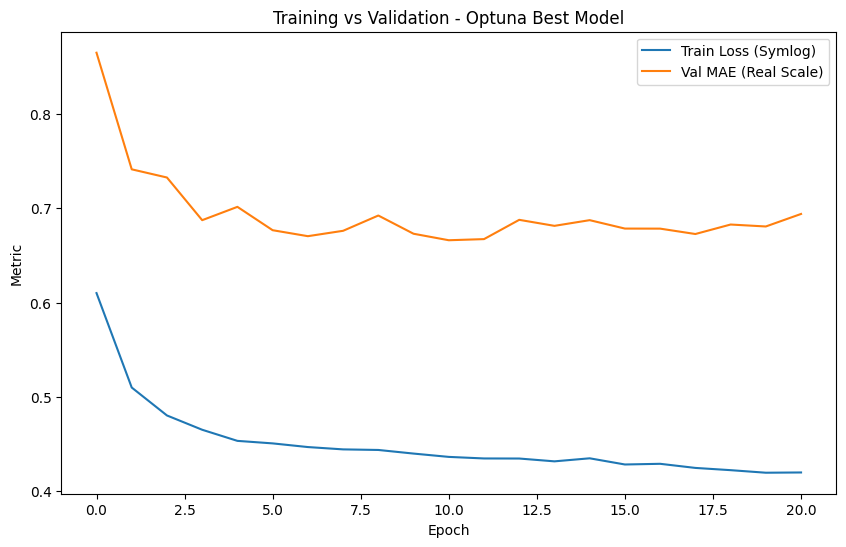

Test MAE  (Real Scale): 0.6032
Test RMSE (Real Scale): 1.0373



In [9]:

print("OPTUNA BEST INITIALIZATION PARAMETERS")
print(f"Best Trial Validation Loss (Symlog Space): {study.best_trial.value:.4f}")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")
print("="*50 + "\n")

optimal_batch_size = study.best_trial.params["batch_size"]
test_dataset = ImprovedYoYDatasetMTL(mtl_test_data, robust_scaler, selected_indices)
test_loader = DataLoader(test_dataset, batch_size=optimal_batch_size, shuffle=False, collate_fn=collate_fn_improved_mtl)

final_model = ImprovedShallow_xLSTM(
    input_size=len(selected_indices),
    hidden_size=study.best_trial.params["hidden_size"],
    num_targets=len(PREDICTION_TARGETS),
    dropout=study.best_trial.params["dropout"],
    block_type=study.best_trial.params["block_type"],
    static_dim=STATIC_DIM
)

print("Executing final training pass to lock-in optimal weights...")
train_loader_final = DataLoader(ImprovedYoYDatasetMTL(mtl_train_data, robust_scaler, selected_indices), batch_size=optimal_batch_size, shuffle=True, collate_fn=collate_fn_improved_mtl)
val_loader_final = DataLoader(ImprovedYoYDatasetMTL(mtl_val_data, robust_scaler, selected_indices), batch_size=optimal_batch_size, shuffle=False, collate_fn=collate_fn_improved_mtl)

result = train_model(
    model=final_model,
    train_loader=train_loader_final,
    val_loader=val_loader_final,
    criterion=nn.L1Loss(),
    lr=study.best_trial.params["lr"],
    weight_decay=study.best_trial.params["weight_decay"],
    epochs=MAX_EPOCHS,
    patience=PATIENCE,
    device=DEVICE
)

plt.figure(figsize=(10, 6))
plt.plot(result["history"]["train_loss"], label="Train Loss (Symlog)")
plt.plot(result["history"]["val_loss"], label="Val MAE (Real Scale)")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Training vs Validation - Optuna Best Model")
plt.legend()
plt.show()

final_model.load_state_dict(torch.torch.load('best_xlstm_model.pth', map_location=DEVICE))
real_mae, real_rmse = evaluate_real_metrics(final_model, test_loader, DEVICE)

In [10]:
per_target_results = evaluate_per_target_metrics(final_model, test_loader, DEVICE, PREDICTION_TARGETS)

--- MAE PER TARGET (REAL SCALE) ---
EBITDA       MAE: 0.4461
Net_Income   MAE: 0.6810
ROA          MAE: 0.6821


Training Hybrid xLSTM (mLSTM -> sLSTM)...
Epoch   1/70 | Train Loss: 0.6138 | Val MAE (Real): 0.9464 | LR: 0.001000
Epoch   2/70 | Train Loss: 0.5387 | Val MAE (Real): 0.8987 | LR: 0.001000
Epoch   3/70 | Train Loss: 0.5099 | Val MAE (Real): 0.8140 | LR: 0.001000
Epoch   4/70 | Train Loss: 0.4884 | Val MAE (Real): 0.7551 | LR: 0.001000
Epoch   5/70 | Train Loss: 0.4771 | Val MAE (Real): 0.7265 | LR: 0.001000
Epoch   6/70 | Train Loss: 0.4650 | Val MAE (Real): 0.7395 | LR: 0.001000
Epoch   7/70 | Train Loss: 0.4592 | Val MAE (Real): 0.6964 | LR: 0.001000
Epoch   8/70 | Train Loss: 0.4511 | Val MAE (Real): 0.7042 | LR: 0.001000
Epoch   9/70 | Train Loss: 0.4502 | Val MAE (Real): 0.7035 | LR: 0.001000
Epoch  10/70 | Train Loss: 0.4467 | Val MAE (Real): 0.6967 | LR: 0.001000
Epoch  11/70 | Train Loss: 0.4426 | Val MAE (Real): 0.6843 | LR: 0.001000
Epoch  12/70 | Train Loss: 0.4437 | Val MAE (Real): 0.7077 | LR: 0.001000
Epoch  13/70 | Train Loss: 0.4424 | Val MAE (Real): 0.6912 | LR: 0.001

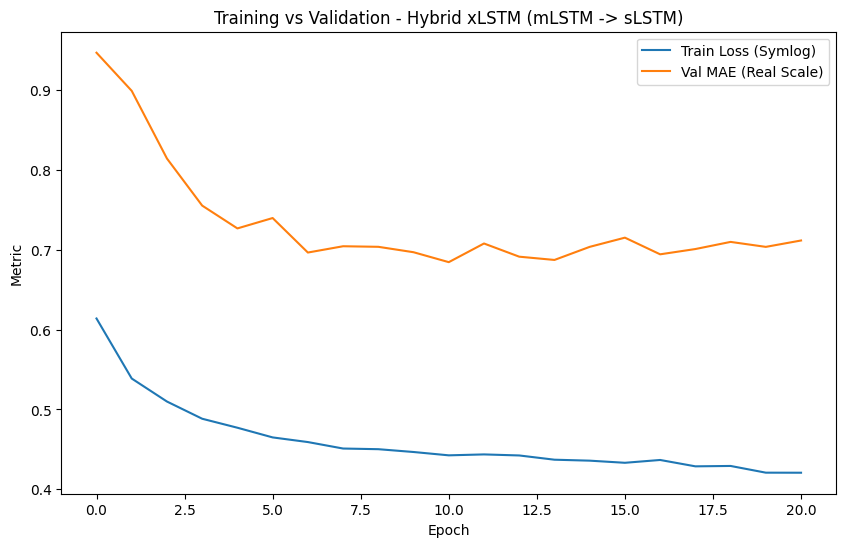


--- HYBRID MODEL OVERALL RESULTS ---
Test MAE  (Real Scale): 0.6228
Test RMSE (Real Scale): 1.0504

--- MAE PER TARGET (REAL SCALE) ---
EBITDA       MAE: 0.4871
Net_Income   MAE: 0.6932
ROA          MAE: 0.6878


In [11]:
class Hybrid_xLSTM(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_targets: int = len(PREDICTION_TARGETS), dropout: float = 0.2, static_dim: int = 0):
        super().__init__()
        self.static_dim = static_dim
        self.proj = nn.Linear(input_size, hidden_size)
        slstm_config = sLSTMLayerConfig(backend='vanilla')

        self.xlstm_config = xLSTMBlockStackConfig(
            slstm_block=sLSTMBlockConfig(slstm=slstm_config),
            mlstm_block=mLSTMBlockConfig(mlstm=mLSTMLayerConfig()),
            context_length=400,
            num_blocks=2,
            embedding_dim=hidden_size,
            slstm_at=[1]  # Index 1 is the second block. Index 0 defaults to mLSTM.
        )

        self.xlstm = xLSTMBlockStack(self.xlstm_config)
        self.dropout = nn.Dropout(p=dropout)
        self.head = nn.Linear(hidden_size + static_dim, num_targets)

    def forward(self, x, lengths, static=None):
        B, S, _ = x.shape
        x_proj = self.proj(x)
        out = self.xlstm(x_proj)
        idx = (lengths - 1).view(-1, 1).expand(-1, out.size(2)).unsqueeze(1).to(out.device)
        last_out = out.gather(1, idx).squeeze(1) # [B, hidden_size]

        hidden = self.dropout(last_out)
        if self.static_dim > 0 and static is not None:
            hidden = torch.cat([hidden, static.to(hidden.device, hidden.dtype)], dim=-1)
        logits = self.head(hidden)

        if logits.size(-1) == 1: logits = logits.squeeze(-1)
        return logits

hybrid_params = {
    'hidden_size': 64,
    'dropout': 0.33,
    'lr': 0.001,
    'weight_decay': 0.002,
    'batch_size': 64
}

print("Training Hybrid xLSTM (mLSTM -> sLSTM)...")

test_dataset = ImprovedYoYDatasetMTL(mtl_test_data, robust_scaler, selected_indices)
test_loader = DataLoader(test_dataset, batch_size=hybrid_params["batch_size"], shuffle=False, collate_fn=collate_fn_improved_mtl)
train_loader_hybrid = DataLoader(ImprovedYoYDatasetMTL(mtl_train_data, robust_scaler, selected_indices), batch_size=hybrid_params["batch_size"], shuffle=True, collate_fn=collate_fn_improved_mtl)
val_loader_hybrid = DataLoader(ImprovedYoYDatasetMTL(mtl_val_data, robust_scaler, selected_indices), batch_size=hybrid_params["batch_size"], shuffle=False, collate_fn=collate_fn_improved_mtl)

hybrid_model = Hybrid_xLSTM(
    input_size=len(selected_indices),
    hidden_size=hybrid_params["hidden_size"],
    num_targets=len(PREDICTION_TARGETS),
    dropout=hybrid_params["dropout"],
    static_dim=STATIC_DIM
)

result = train_model(
    model=hybrid_model,
    train_loader=train_loader_hybrid,
    val_loader=val_loader_hybrid,
    criterion=nn.L1Loss(),
    lr=hybrid_params["lr"],
    weight_decay=hybrid_params["weight_decay"],
    epochs=MAX_EPOCHS,
    patience=PATIENCE,
    device=DEVICE
)

plt.figure(figsize=(10, 6))
plt.plot(result["history"]["train_loss"], label="Train Loss (Symlog)")
plt.plot(result["history"]["val_loss"], label="Val MAE (Real Scale)")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Training vs Validation - Hybrid xLSTM (mLSTM -> sLSTM)")
plt.legend()
plt.show()

hybrid_model.load_state_dict(torch.load('best_xlstm_model.pth', map_location=DEVICE))
print("\n--- HYBRID MODEL OVERALL RESULTS ---")
real_mae_hybrid, real_rmse_hybrid = evaluate_real_metrics(hybrid_model, test_loader, DEVICE)
per_target_results_hybrid = evaluate_per_target_metrics(hybrid_model, test_loader, DEVICE, PREDICTION_TARGETS)

## Trained vs Untrained Baseline (xLSTM)

20-seed comparison: trained model vs random-init baseline, using the best shallow xLSTM params.
Confirms the model learns (trained MAE < untrained MAE) after winsorization + fundamental features.


In [12]:
N_RUNS_BASELINE = 20

def set_seed_b(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def evaluate_loader_xlstm(model, loader, device):
    """Silent per-target MAE in real space (no print)."""
    model.eval()
    all_preds, all_targets, all_masks = [], [], []
    with torch.no_grad():
        for x_batch, y_batch, mask_batch, static_batch, lengths in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            mask_batch = mask_batch.to(device)
            static_batch = static_batch.to(device)
            lengths = lengths.to(device)
            preds = model(x_batch, lengths, static_batch)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())
            all_masks.append(mask_batch.cpu().numpy())
    y_pred = np.vstack(all_preds)
    y_true = np.vstack(all_targets)
    mask = np.vstack(all_masks).astype(bool)
    y_pred = np.clip(y_pred, -SYMLOG_CAP, SYMLOG_CAP)
    y_pred = np.sign(y_pred) * np.expm1(np.abs(y_pred))
    y_true = np.sign(y_true) * np.expm1(np.abs(y_true))
    res = {}
    all_errors = []
    for i, t in enumerate(PREDICTION_TARGETS):
        m = mask[:, i]
        if m.sum() == 0:
            continue
        res[t] = np.mean(np.abs(y_pred[m, i] - y_true[m, i]))
        all_errors.extend(np.abs(y_pred[m, i] - y_true[m, i]).tolist())
    res["Overall"] = np.mean(all_errors) if all_errors else None
    return res

best_shallow_params = study.best_trial.params
trained_res   = {t: [] for t in PREDICTION_TARGETS + ["Overall"]}
untrained_res = {t: [] for t in PREDICTION_TARGETS + ["Overall"]}

test_ds_base = ImprovedYoYDatasetMTL(mtl_test_data, robust_scaler, selected_indices)
test_loader_base = DataLoader(test_ds_base, batch_size=best_shallow_params["batch_size"],
                               shuffle=False, collate_fn=collate_fn_improved_mtl)

for run_idx in range(N_RUNS_BASELINE):
    set_seed_b(SEED + run_idx)
    model_u = ImprovedShallow_xLSTM(
        input_size=len(selected_indices),
        hidden_size=best_shallow_params["hidden_size"],
        num_targets=len(PREDICTION_TARGETS),
        dropout=best_shallow_params["dropout"],
        block_type=best_shallow_params["block_type"],
        static_dim=STATIC_DIM
    ).to(DEVICE)
    for k, v in evaluate_loader_xlstm(model_u, test_loader_base, DEVICE).items():
        untrained_res[k].append(v)

    set_seed_b(SEED + run_idx)
    model_t = ImprovedShallow_xLSTM(
        input_size=len(selected_indices),
        hidden_size=best_shallow_params["hidden_size"],
        num_targets=len(PREDICTION_TARGETS),
        dropout=best_shallow_params["dropout"],
        block_type=best_shallow_params["block_type"],
        static_dim=STATIC_DIM
    ).to(DEVICE)
    train_ds_t = ImprovedYoYDatasetMTL(mtl_train_data, robust_scaler, selected_indices)
    val_ds_t   = ImprovedYoYDatasetMTL(mtl_val_data, robust_scaler, selected_indices)
    train_loader_t = DataLoader(train_ds_t, batch_size=best_shallow_params["batch_size"],
                                 shuffle=True, collate_fn=collate_fn_improved_mtl)
    val_loader_t   = DataLoader(val_ds_t, batch_size=best_shallow_params["batch_size"],
                                 shuffle=False, collate_fn=collate_fn_improved_mtl)
    train_model(model_t, train_loader_t, val_loader_t, nn.L1Loss(),
                best_shallow_params["lr"], best_shallow_params["weight_decay"],
                MAX_EPOCHS, PATIENCE, DEVICE)
    for k, v in evaluate_loader_xlstm(model_t, test_loader_base, DEVICE).items():
        trained_res[k].append(v)

rows = []
for k in PREDICTION_TARGETS + ["Overall"]:
    rows.append({
        "Target": k,
        "Untrained MAE": np.mean(untrained_res[k]),
        "Untrained +/-": np.std(untrained_res[k]),
        "Trained MAE": np.mean(trained_res[k]),
        "Trained +/-": np.std(trained_res[k]),
        "Delta (Trained - Untrained)": np.mean(trained_res[k]) - np.mean(untrained_res[k]),
    })
df_baseline_cmp = pd.DataFrame(rows).set_index("Target")
print(f"\nxLSTM Trained vs Untrained - Test MAE (real space), {N_RUNS_BASELINE} runs:")
display(df_baseline_cmp.round(4))


Epoch   1/70 | Train Loss: 0.6174 | Val MAE (Real): 0.7424 | LR: 0.003601
Epoch   2/70 | Train Loss: 0.5181 | Val MAE (Real): 0.6890 | LR: 0.003601
Epoch   3/70 | Train Loss: 0.4830 | Val MAE (Real): 0.6815 | LR: 0.003601
Epoch   4/70 | Train Loss: 0.4677 | Val MAE (Real): 0.6790 | LR: 0.003601
Epoch   5/70 | Train Loss: 0.4581 | Val MAE (Real): 0.6612 | LR: 0.003601
Epoch   6/70 | Train Loss: 0.4522 | Val MAE (Real): 0.6708 | LR: 0.003601
Epoch   7/70 | Train Loss: 0.4487 | Val MAE (Real): 0.6676 | LR: 0.003601
Epoch   8/70 | Train Loss: 0.4445 | Val MAE (Real): 0.6816 | LR: 0.003601
Epoch   9/70 | Train Loss: 0.4442 | Val MAE (Real): 0.6726 | LR: 0.003601
Epoch  10/70 | Train Loss: 0.4413 | Val MAE (Real): 0.6626 | LR: 0.003601
Epoch  11/70 | Train Loss: 0.4396 | Val MAE (Real): 0.6808 | LR: 0.001800
Epoch  12/70 | Train Loss: 0.4382 | Val MAE (Real): 0.6718 | LR: 0.001800
Epoch  13/70 | Train Loss: 0.4367 | Val MAE (Real): 0.6788 | LR: 0.001800
Epoch  14/70 | Train Loss: 0.4349 | Va

,Untrained MAE,Untrained +/-,Trained MAE,Trained +/-,Delta (Trained - Untrained)
Target,,,,,
EBITDA,1.1728,0.6132,0.4586,0.0195,-0.7142
Net_Income,1.2542,0.5442,0.6933,0.0195,-0.5609
ROA,1.1779,0.4970,0.6952,0.0154,-0.4827
Overall,1.2017,0.2646,0.6159,0.0175,-0.5859
